# 🩺 Diabetes Dataset — Classification & Regression
**Dataset:** Pima Indians Diabetes Dataset  
**Tasks:**
- **Classification** → Predict whether a patient has diabetes (`Outcome`: 0 or 1) using a **Decision Tree**
- **Regression** → Predict a patient's **Glucose** level using a **Linear Regression** model

---

## 📦 Step 1 — Import Libraries

We need:
- `pandas` → load and manipulate the dataset
- `sklearn` → machine learning models and evaluation tools
- `matplotlib` / `seaborn` → visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

# Make plots look clean
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

Matplotlib is building the font cache; this may take a moment.


---
## 📂 Step 2 — Load the Dataset

Make sure `diabetes.csv` is in the **same folder** as this notebook.

In [2]:
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)   # (rows, columns)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## 🔍 Step 3 — Explore the Data (EDA)

Before building any model, we need to understand what we're working with.

In [3]:
# Basic statistics for every column
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome value counts:
Outcome
0    500
1    268
Name: count, dtype: int64


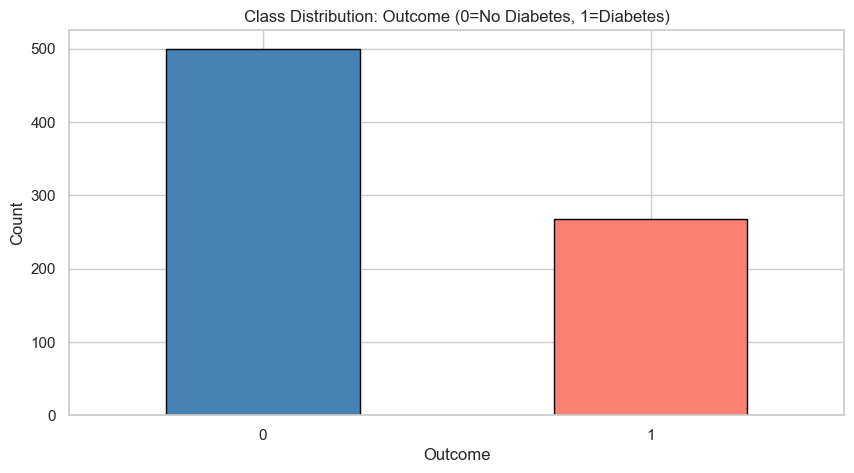

In [5]:
# Check class balance for Classification target
print('Outcome value counts:')
print(df['Outcome'].value_counts())

df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution: Outcome (0=No Diabetes, 1=Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

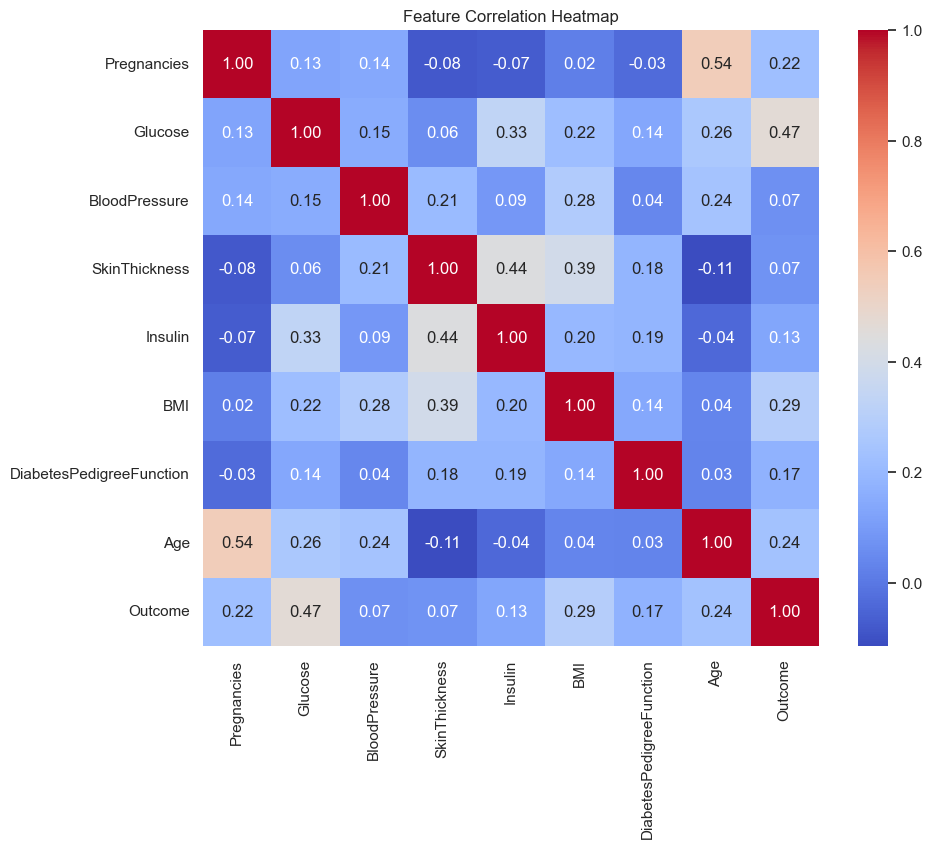

In [6]:
# Correlation heatmap — shows how features relate to each other
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

---
## 🌳 PART A — Classification with Decision Tree

**Goal:** Predict `Outcome` (0 = no diabetes, 1 = diabetes)

### Step A1 — Prepare Features and Target

- **X** = all columns except `Outcome` (these are our input features)
- **y** = the `Outcome` column (this is what we want to predict)

In [7]:
X_clf = df.drop('Outcome', axis=1)   # Features
y_clf = df['Outcome']                # Target

print('Features shape:', X_clf.shape)
print('Target shape:', y_clf.shape)

Features shape: (768, 8)
Target shape: (768,)


### Step A2 — Split into Train and Test Sets

We split the data: **80% for training** the model, **20% for testing** it.

`random_state=42` just fixes the random seed so results are reproducible.

In [8]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train_clf.shape[0]}')
print(f'Testing samples:  {X_test_clf.shape[0]}')

Training samples: 614
Testing samples:  154


### Step A3 — Train the Decision Tree

`max_depth=4` limits the tree to 4 levels so it doesn't overfit (memorize the training data).

In [9]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train_clf, y_train_clf)

print('Decision Tree trained successfully!')

Decision Tree trained successfully!


### Step A4 — Make Predictions & Evaluate

Key metrics:
- **Accuracy** → % of correct predictions overall
- **Confusion Matrix** → shows true positives, false positives, etc.
- **Classification Report** → precision, recall, F1-score per class

In [10]:
y_pred_clf = dt_model.predict(X_test_clf)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f'Accuracy: {accuracy * 100:.2f}%\n')

print('Classification Report:')
print(classification_report(y_test_clf, y_pred_clf, target_names=['No Diabetes', 'Diabetes']))

Accuracy: 69.48%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.70      0.75        99
    Diabetes       0.56      0.69      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.72      0.69      0.70       154



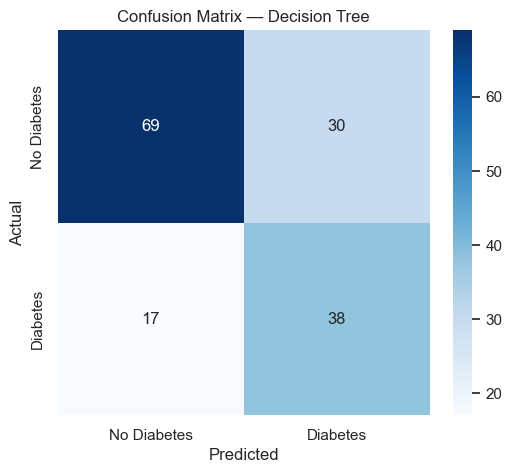

In [11]:
# Confusion Matrix visualization
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Step A5 — Visualize the Decision Tree

This shows the actual decision rules the model learned.

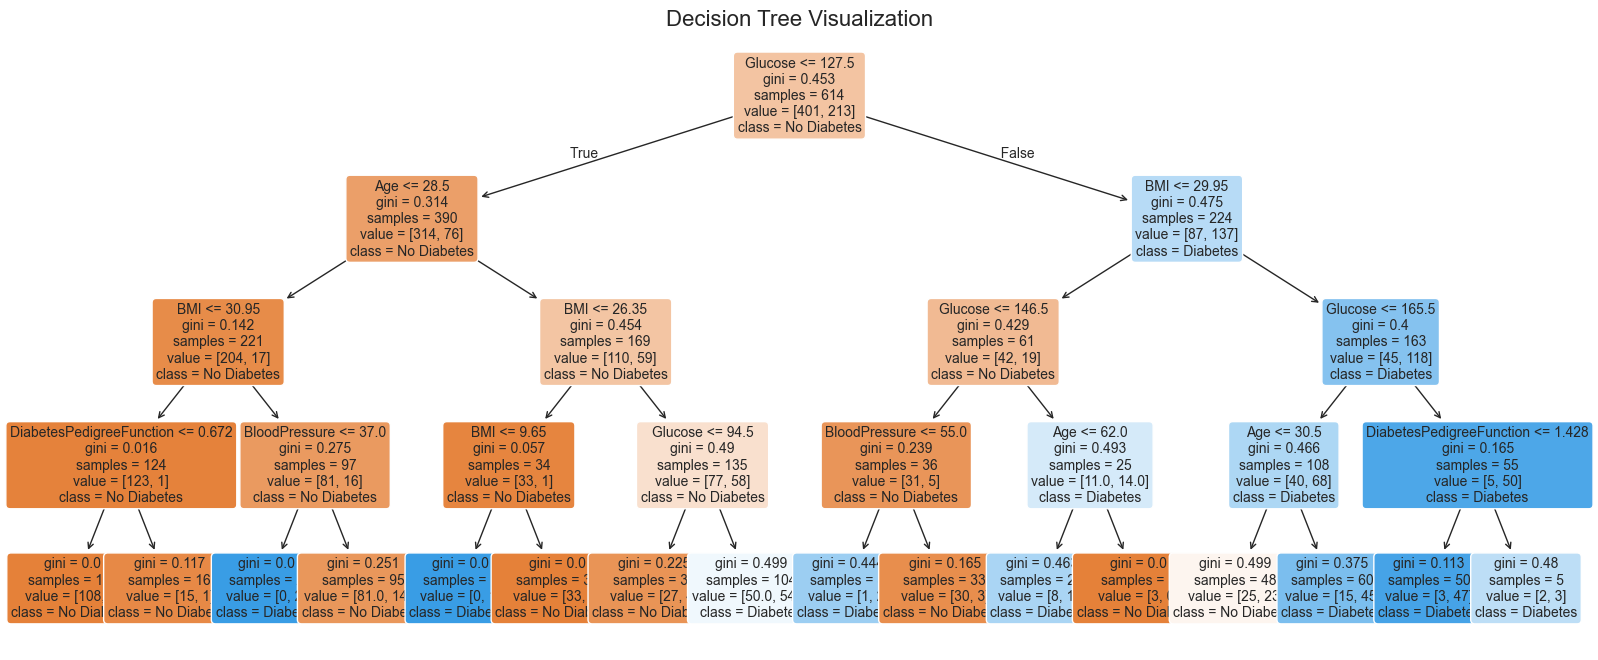

In [12]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X_clf.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Visualization', fontsize=16)
plt.show()

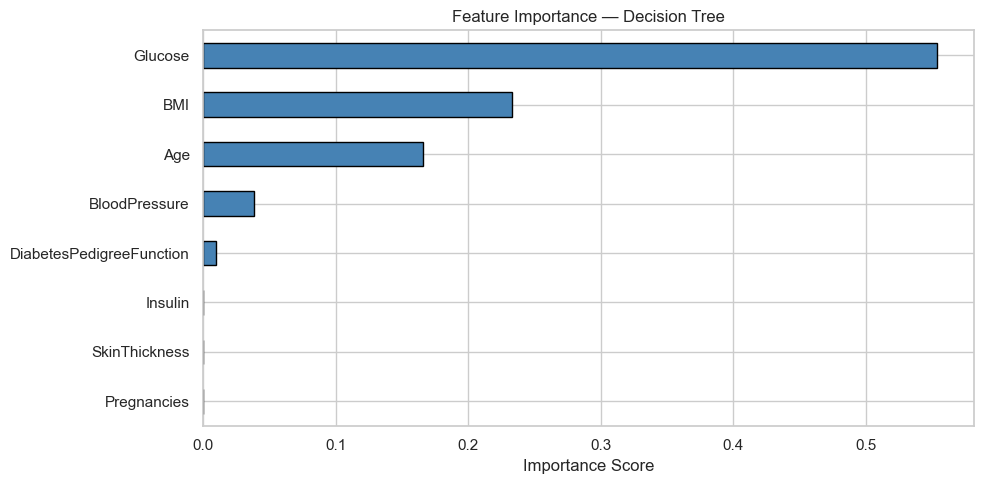

In [13]:
# Feature importance — which features matter most?
importances = pd.Series(dt_model.feature_importances_, index=X_clf.columns)
importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 📈 PART B — Regression with Linear Regression

**Goal:** Predict `Glucose` level (a continuous number) from the other features.

We drop `Glucose` from features and use it as the target.

### Step B1 — Prepare Features and Target

In [14]:
X_reg = df.drop('Glucose', axis=1)   # All columns except Glucose
y_reg = df['Glucose']                # Target: predict Glucose

print('Features shape:', X_reg.shape)
print('Target shape:', y_reg.shape)
print(f'Glucose range: {y_reg.min()} – {y_reg.max()}')

Features shape: (768, 8)
Target shape: (768,)
Glucose range: 0 – 199


### Step B2 — Split into Train and Test Sets

In [15]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train_reg.shape[0]}')
print(f'Testing samples:  {X_test_reg.shape[0]}')

Training samples: 614
Testing samples:  154


### Step B3 — Train the Linear Regression Model

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

print('Linear Regression trained successfully!')

# Show the learned coefficients
coeff_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\nIntercept: {lr_model.intercept_:.4f}')
print('\nCoefficients:')
print(coeff_df.to_string(index=False))

Linear Regression trained successfully!

Intercept: 78.3579

Coefficients:
                 Feature  Coefficient
                 Outcome    23.800274
DiabetesPedigreeFunction     4.427758
                     Age     0.409477
                     BMI     0.304652
           BloodPressure     0.136719
                 Insulin     0.098801
             Pregnancies    -0.149322
           SkinThickness    -0.393792


### Step B4 — Make Predictions & Evaluate

Key regression metrics:
- **MAE** (Mean Absolute Error) → average absolute difference between predicted and actual values
- **MSE** (Mean Squared Error) → like MAE but penalizes large errors more
- **RMSE** → square root of MSE, in the same unit as the target (mg/dL)
- **R² Score** → how much variance the model explains (1.0 = perfect, 0 = no better than just guessing the mean)

In [17]:
y_pred_reg = lr_model.predict(X_test_reg)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
mse  = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_reg, y_pred_reg)

print(f'MAE  (Mean Absolute Error):  {mae:.2f} mg/dL')
print(f'MSE  (Mean Squared Error):   {mse:.2f}')
print(f'RMSE (Root MSE):             {rmse:.2f} mg/dL')
print(f'R²   Score:                  {r2:.4f}')

MAE  (Mean Absolute Error):  20.61 mg/dL
MSE  (Mean Squared Error):   704.68
RMSE (Root MSE):             26.55 mg/dL
R²   Score:                  0.2997


### Step B5 — Visualize: Actual vs Predicted

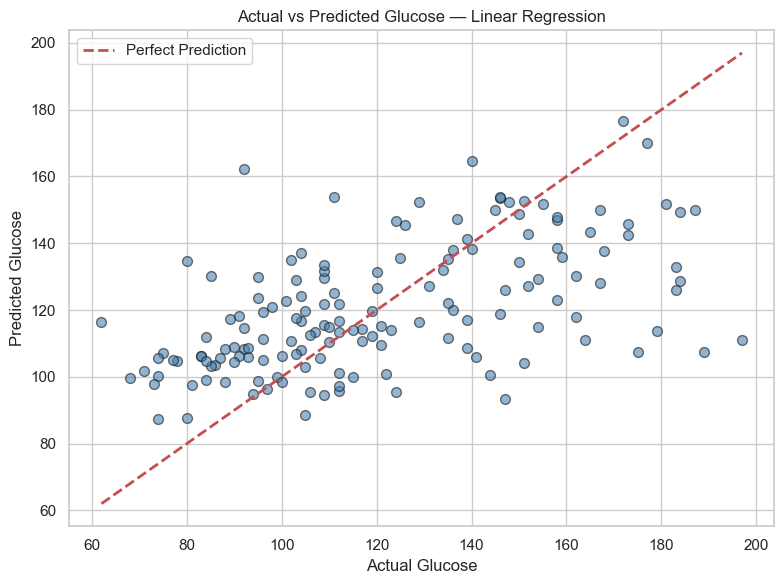

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue', edgecolors='k', s=50)

# Perfect prediction line
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Glucose — Linear Regression')
plt.xlabel('Actual Glucose')
plt.ylabel('Predicted Glucose')
plt.legend()
plt.tight_layout()
plt.show()

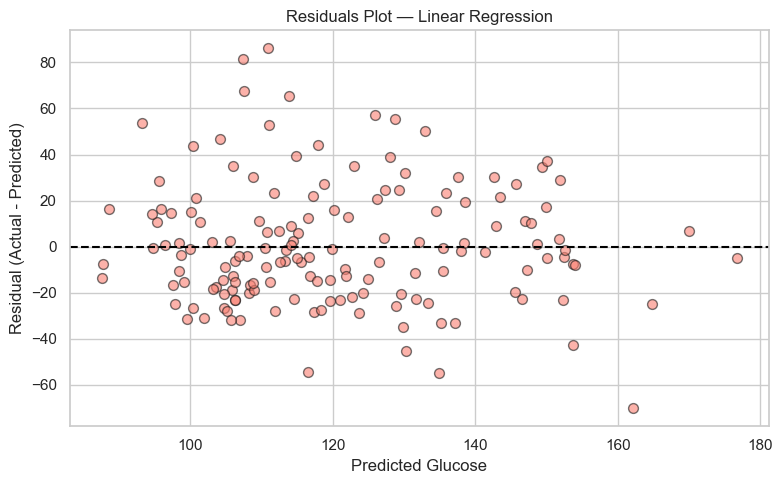

In [19]:
# Residuals plot — should look random if the model is good
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_reg, residuals, alpha=0.6, color='salmon', edgecolors='k', s=50)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Residuals Plot — Linear Regression')
plt.xlabel('Predicted Glucose')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

---
## ✅ Summary

| Task | Model | Target | Key Metric |
|------|-------|--------|------------|
| Classification | Decision Tree | `Outcome` (0 or 1) | Accuracy, F1-Score |
| Regression | Linear Regression | `Glucose` (continuous) | R², RMSE |

### How to interpret results:
- **Classification accuracy ~75%** is typical for this dataset with a basic Decision Tree
- **R² around 0.2–0.4** for Glucose regression is expected — Glucose is hard to predict from these features alone
- The confusion matrix tells you exactly where the classifier is making mistakes (e.g., false negatives = missed diabetic cases)
- The residuals plot being randomly scattered around 0 means no major systematic error in regression